---
# 📁 **ATIVIDADE FIAP - Cap 1 - Gestão de Crises com Sistema Preditivo em IA**
---

**Autor.....:** Diego Nunes Veiga

**RM........:** 560658

**Turma...:** Graduação - 2TIAOR

**Data......:** 26/04/2026

---

---
## **↪ Bibliotecas**
---


In [131]:
!pip install pydantic openai-agents joblib

In [132]:
# Bibliotecas padrão
import os

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Validação de dados
from pydantic import BaseModel, Field

# Sistema Multiagente
from agents import Agent, Runner, function_tool, handoff, set_tracing_disabled

# Ambiente Colab
from google.colab import userdata

In [133]:
# Gera dados simulados conforme exercício
#--------------------------------------------------------------

np.random.seed(42)

qtd_registros = 1000

df = pd.DataFrame({
    "idade": np.random.randint(18, 90, qtd_registros),
    "frequencia_cardiaca": np.random.randint(55, 160, qtd_registros),
    "spo2": np.random.randint(85, 100, qtd_registros),
    "pressao_sistolica": np.random.randint(90, 190, qtd_registros),
    "pressao_diastolica": np.random.randint(60, 120, qtd_registros),
    "carga_sistema": np.random.uniform(0.1, 1.0, qtd_registros),
    "disponibilidade_recursos": np.random.uniform(0.1, 1.0, qtd_registros)
})

---
## **↪ API**
---

In [134]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_AGENTS_DISABLE_TRACING"] = "1"
set_tracing_disabled(True)

---
## **↪ Subalgoritmos**
---


In [135]:
# Função para avaliação de risco do paciente
#--------------------------------------------------------------

def GerarPicoRisco(linha):
    score = 0

    if linha["idade"] >= 60:                         score += 1
    if linha["frequencia_cardiaca"] >= 120:          score += 2
    if linha["spo2"] <= 92:                          score += 2
    if linha["pressao_sistolica"] >= 140:            score += 1
    if linha["pressao_diastolica"] >= 100:           score += 1
    if linha["carga_sistema"] >= 0.75:               score += 1
    if linha["disponibilidade_recursos"] <= 0.35:    score += 1

    return 1 if score >= 4 else 0

df["pico_risco"] = df.apply(GerarPicoRisco, axis=1)

In [136]:
# Função de divisão do treino, validação e teste
# ---------------------------------------------------------------------------

def TreinaValidacao(X, y, rdm_state,tamanho_teste):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = tamanho_teste,
        random_state = rdm_state,
        stratify = y
    )

    return X_train, X_test, y_train, y_test

In [137]:
# Função de treinamento do modelo
# ---------------------------------------------------------------------------

def TreinaModelo(X_train, X_test, y_train, y_test):
    modelo = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
    modelo.fit(X_train, y_train)

    # Apresenta as divisões
    print(f'Tamanho do conjunto de dados original: {X.shape}')
    print(f'Tamanho do conjunto de treinamento: {X_train.shape}')
    print(f'Tamanho do conjunto de teste: {X_test.shape}')

    return modelo


In [138]:
# Função de execução da Floresta Aleatória
# ---------------------------------------------------------------------------

def FlorestaAleatoria(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    mod = "Floresta Aleatória"
    acuracia = accuracy_score(y_test, y_pred)
    matriz = confusion_matrix(y_test, y_pred)
    relatorio = classification_report(y_test, y_pred)

    # Apresenta relatório
    print(relatorio)

    return mod, acuracia, matriz

In [139]:
# Função de Apresentação dos resultados
# ---------------------------------------------------------------------------

def ApresentaResultado(mod, acuracia, matriz):

    print("===== RESULTADOS DO MODELO =====")

    # Modelo utilizado
    print(f"Modelo: {mod}")

    # Acurácia
    print(f"Acurácia: {acuracia:.4f}")

    # Matriz de confusão
    print("\nMatriz de Confusão:")
    plt.figure(figsize=(6,5))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Sem Risco", "Com Risco"],
                yticklabels=["Sem Risco", "Com Risco"])
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()


In [140]:
# Classe de resposta da saída final do Multiagente
# ---------------------------------------------------------------------------

class SaidaFinal(BaseModel):
    probabilidade_prevista: float = Field(ge=0, le=1)
    classificacao_risco: str
    protocolos_sugeridos: list[str]
    justificativa: str

---
# **PROGRAMA PRINCIPAL**
---

### **PARTE 1**

### **↪ Apresentação dos dados simulados**

In [141]:
# Apresentação dos dados simulados
# ---------------------------------------------------------------------------

df.head(len(df))

,idade,frequencia_cardiaca,spo2,pressao_sistolica,pressao_diastolica,carga_sistema,disponibilidade_recursos,pico_risco
0,69,61,99,164,75,0.498976,0.725188,0
1,32,147,89,109,68,0.598042,0.428204,1
2,89,62,87,177,68,0.329394,0.764655,1
3,78,119,96,104,97,0.768278,0.699955,0
4,38,111,97,137,70,0.168972,0.207606,0
...,...,...,...,...,...,...,...,...
995,27,139,90,171,64,0.528815,0.462728,1
996,51,69,99,102,60,0.386474,0.671101,0
997,72,119,99,189,63,0.540132,0.659068,0
998,49,130,86,120,71,0.873601,0.208672,1


### **↪ Treinamento do modelo**

In [142]:
# Divisão dos dados para treinamento
# ---------------------------------------------------------------------------

# Separando os valores para o eixo X
X = df.drop("pico_risco", axis=1)

# Separando os valores para o eixo Y
y = df["pico_risco"]

In [143]:
# Treinamento de Validação: 70% treino / 15% validação / 15% teste
# ---------------------------------------------------------------------------

X_train, X_test, y_train, y_test = TreinaValidacao(X, y, 42, 0.3)

In [144]:
# Treinamento do modelo
# ---------------------------------------------------------------------------

modeloRF = TreinaModelo(X_train, X_test, y_train, y_test)

Tamanho do conjunto de dados original: (1000, 7)
Tamanho do conjunto de treinamento: (700, 7)
Tamanho do conjunto de teste: (300, 7)


### **↪ Modelo Preditivo**

In [145]:
# Execução do machine learning
# ---------------------------------------------------------------------------

mod, acuracia, matriz = FlorestaAleatoria(modeloRF, X_test, y_test)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       142
           1       0.94      0.96      0.95       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



===== RESULTADOS DO MODELO =====
Modelo: Floresta Aleatória
Acurácia: 0.9433

Matriz de Confusão:


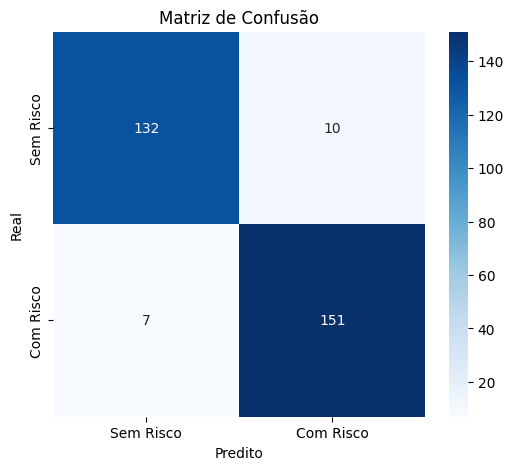

In [146]:
# Apresentação dos resultados obtidos
# ---------------------------------------------------------------------------

ApresentaResultado(mod, acuracia, matriz)

In [147]:
# Salvamente do modelo de Machine Learning
# ---------------------------------------------------------------------------

joblib.dump(modeloRF, "modelo_pico_risco.pkl")

['modelo_pico_risco.pkl']

### **PARTE 2**

---
## **↪ Funções de Ferramenta**
---

In [148]:
# Carrega o modelo de Machine Learning
# ---------------------------------------------------------------------------

modeloRF = joblib.load("modelo_pico_risco.pkl")

In [149]:
# Function tool do modelo preditivo
# ---------------------------------------------------------------------------

@function_tool
def consultar_modelo_preditivo(
    idade: int,
    frequencia_cardiaca: int,
    spo2: int,
    pressao_sistolica: int,
    pressao_diastolica: int,
    carga_sistema: float,
    disponibilidade_recursos: float
) -> dict:

    paciente = pd.DataFrame([{
        "idade": idade,
        "frequencia_cardiaca": frequencia_cardiaca,
        "spo2": spo2,
        "pressao_sistolica": pressao_sistolica,
        "pressao_diastolica": pressao_diastolica,
        "carga_sistema": carga_sistema,
        "disponibilidade_recursos": disponibilidade_recursos
    }])

    # Tratativa da probabilidade de risco
    prob = modeloRF.predict_proba(paciente)[0][1]
    classe = int(modeloRF.predict(paciente)[0])

    if prob >= 0.75:     risco = "ALTO"
    elif prob >= 0.45:   risco = "MODERADO"
    else:                risco = "BAIXO"

    # Tratativa da Classificação de risco
    classe_texto = "Com risco" if classe else "Sem risco"

    return {
        "probabilidade_prevista": f"{round(float(prob)*100, 2)} %",
        "classe_prevista": classe_texto,
        "classificacao_risco": risco
    }

In [150]:
# Function tool do protocolo médico
# ---------------------------------------------------------------------------

@function_tool
def consultar_protocolos_medicos(classificacao_risco: str) -> dict:

    base_protocolos = {
        "BAIXO": [
            "Monitoramento periódico dos sinais vitais.",
            "Orientar acompanhamento clínico preventivo.",
            "Registrar nova avaliação em caso de piora dos sintomas."
        ],
        "MODERADO": [
            "Reavaliar sinais vitais em curto intervalo.",
            "Encaminhar para avaliação médica prioritária.",
            "Monitorar pressão arterial, frequência cardíaca e saturação."
        ],
        "ALTO": [
            "Acionar protocolo de emergência cardiovascular.",
            "Priorizar atendimento imediato.",
            "Realizar monitoramento contínuo dos sinais vitais.",
            "Encaminhar para avaliação médica urgente."
        ]
    }

    return {"protocolos_sugeridos": base_protocolos.get(classificacao_risco.upper(), [])}

---
## **↪ Agentes**
---

In [151]:
# Agente de Analista de Riscos
# ---------------------------------------------------------------------------

agente_analista_risco = Agent(
    name="Agente Analista de Risco",
    instructions="""
    Você deve usar obrigatoriamente a tool consultar_modelo_preditivo.
    Retorne probabilidade prevista, classe prevista e classificação de risco.
    Não gere protocolos médicos.
    """,
    tools=[consultar_modelo_preditivo],
    model="gpt-4o-mini"
)

In [152]:
# Agente de Especialista em Protocolos
# ---------------------------------------------------------------------------

agente_protocolos = Agent(
    name="Agente Especialista em Protocolos",
    instructions="""
    Você deve usar obrigatoriamente a tool consultar_protocolos_medicos.
    Receba a classificação de risco e retorne os protocolos médicos simulados.
    """,
    tools=[consultar_protocolos_medicos],
    model="gpt-4o-mini"
)

In [153]:
# Agente Orquestrador
# ---------------------------------------------------------------------------

agente_orquestrador = Agent(
    name="Agente Orquestrador",
    instructions="""
    Coordene o fluxo:
    1. Envie os dados do paciente ao Agente Analista de Risco.
    2. Use a classificação obtida para consultar o Agente Especialista em Protocolos.
    3. Gere uma resposta final estruturada com:
       - probabilidade prevista;
       - classificação de risco;
       - protocolos sugeridos;
    """,
    handoffs=[handoff(agente_analista_risco),
              handoff(agente_protocolos)],
    model="gpt-4o-mini"
)

---
## **↪ Execução do Multiagente**
---

In [160]:
# Paciente teste para a validação do sistema
# ---------------------------------------------------------------------------

paciente_teste = {
    "idade": 80,
    "pressao_sistolica": 170,
    "pressao_diastolica": 120,
    "frequencia_cardiaca": 110,
    "saturacao": 85,
    "temperatura": 37.8,
}

In [161]:
# Input para o Agente Osquertrador
# ---------------------------------------------------------------------------

pergunta = "Analise o seguinte paciente e gere a recomendação final"

input = f"""
{pergunta}

Dados do paciente:
{paciente_teste}
"""

In [162]:
# Execução do Agente Osquertrador
# ---------------------------------------------------------------------------

async def run_agent():
  resultado = await Runner.run(agente_orquestrador, input)
  print(resultado.final_output)

await run_agent()

### Recomendações para o Paciente:

- **Idade:** 80 anos
- **Pressão Arterial:** 170/120 mmHg
- **Frequência Cardíaca:** 110 bpm
- **Saturação de Oxigênio (SpO2):** 85%
- **Temperatura:** 37.8°C

#### Resultados da Análise:
- **Probabilidade Prevista:** 85.0%
- **Classe Prevista:** Com risco
- **Classificação de Risco:** ALTO

### Observações:
O paciente apresenta sinais clínicos indicativos de risco elevado. É recomendável uma avaliação médica imediata e intervenções apropriadas.
